# Pattern Analysis — Cross-Target Insights

**Proposito:** Analizar las relaciones entre frustracion, intencion, churn y resolucion a traves de los 3 modelos entrenados. Identificar patrones, correlaciones y generar insights accionables para el dashboard.

- Dataset: `data/processed/data_preprocessed.csv`
- Modelos: `models/frustration_model.pkl`, `models/intent_model.pkl`, `models/churn_model.pkl`
- Outputs: patrones por flujo, intent, agente y tiempo + metricas agregadas

## 1. IMPORTS Y CONFIGURACION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import json
from pathlib import Path

warnings.filterwarnings('ignore')

# Constantes
RANDOM_STATE = 42
DATA_PATH = Path('../data/processed/data_preprocessed.csv')
MODELS_PATH = Path('../models/')
FIGURES_PATH = Path('../reports/figures/')
FIGURES_PATH.mkdir(exist_ok=True)

# Plotting
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('Setup completo')

Setup completo


## 2. CARGA DE DATOS Y MODELOS

### 2.1 Cargar dataset

In [2]:
df = pd.read_csv(DATA_PATH)
df['fecha'] = pd.to_datetime(df['fecha'])
df['month'] = df['fecha'].dt.to_period('M').astype(str)

print(f'Dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Rango temporal: {df["fecha"].min()} a {df["fecha"].max()}')
print(f'Sesiones unicas: {df["session_id"].nunique()}')
print(f'Agentes unicos: {df["usuario"].nunique()}')

Dataset: 20001 filas x 16 columnas
Rango temporal: 2025-11-08 00:58:48 a 2026-05-07 00:52:07
Sesiones unicas: 6648
Agentes unicos: 540


### 2.2 Cargar modelos y predecir

In [3]:
# Cargar los 3 pipelines
frustration_pipeline = joblib.load(MODELS_PATH / 'frustration_model.pkl')
intent_pipeline = joblib.load(MODELS_PATH / 'intent_model.pkl')
churn_pipeline = joblib.load(MODELS_PATH / 'churn_model.pkl')

# Preparar DataFrame para frustration model (espera 'texto', no 'texto_clean')
pred_df = pd.DataFrame({
    'texto': np.asarray(df['texto_clean']),
    'turn_number': np.asarray(df['turn_number']),
    'flow_name': np.asarray(df['flow_name']),
    'usuario': np.asarray(df['usuario'])
})

# Predecir sobre el dataset completo
df['pred_frustracion'] = frustration_pipeline.predict(pred_df)
df['pred_intencion'] = intent_pipeline.predict(np.asarray(df['texto_clean']))
df['pred_churn'] = churn_pipeline.predict(np.asarray(df['texto_clean']))


## 3. ANALISIS POR FLUJO E INTENCION

### 3.1 Frustracion por flow_name

In [4]:
# Frustracion promedio por flow
flow_frust = df.groupby('flow_name')['nivel_frustracion'].agg(['mean', 'std', 'count']).round(3)
flow_frust.columns = ['Frustracion promedio', 'Std', 'Cantidad de turnos']
flow_frust = flow_frust.sort_values('Frustracion promedio', ascending=False)
print('Frustracion promedio por flujo:')
display(flow_frust)

# Heatmap: frustracion x flow
ct_frust_flow = pd.crosstab(df['flow_name'], df['nivel_frustracion'], normalize='index')
print('\nDistribucion de frustracion por flujo (proporcion por fila):')
display(ct_frust_flow.round(3))

Frustracion promedio por flujo:


,Frustracion promedio,Std,Cantidad de turnos
flow_name,,,
Facturación y Cobros,0.583,0.702,4962
Gestion de Cuenta,0.569,0.694,4983
Soporte Técnico y Despacho,0.569,0.693,5046
Acceso y Seguridad,0.558,0.687,5010



Distribucion de frustracion por flujo (proporcion por fila):


nivel_frustracion,0,1,2
flow_name,,,
Acceso y Seguridad,0.554,0.333,0.113
Facturación y Cobros,0.542,0.333,0.125
Gestion de Cuenta,0.549,0.333,0.118
Soporte Técnico y Despacho,0.549,0.333,0.118


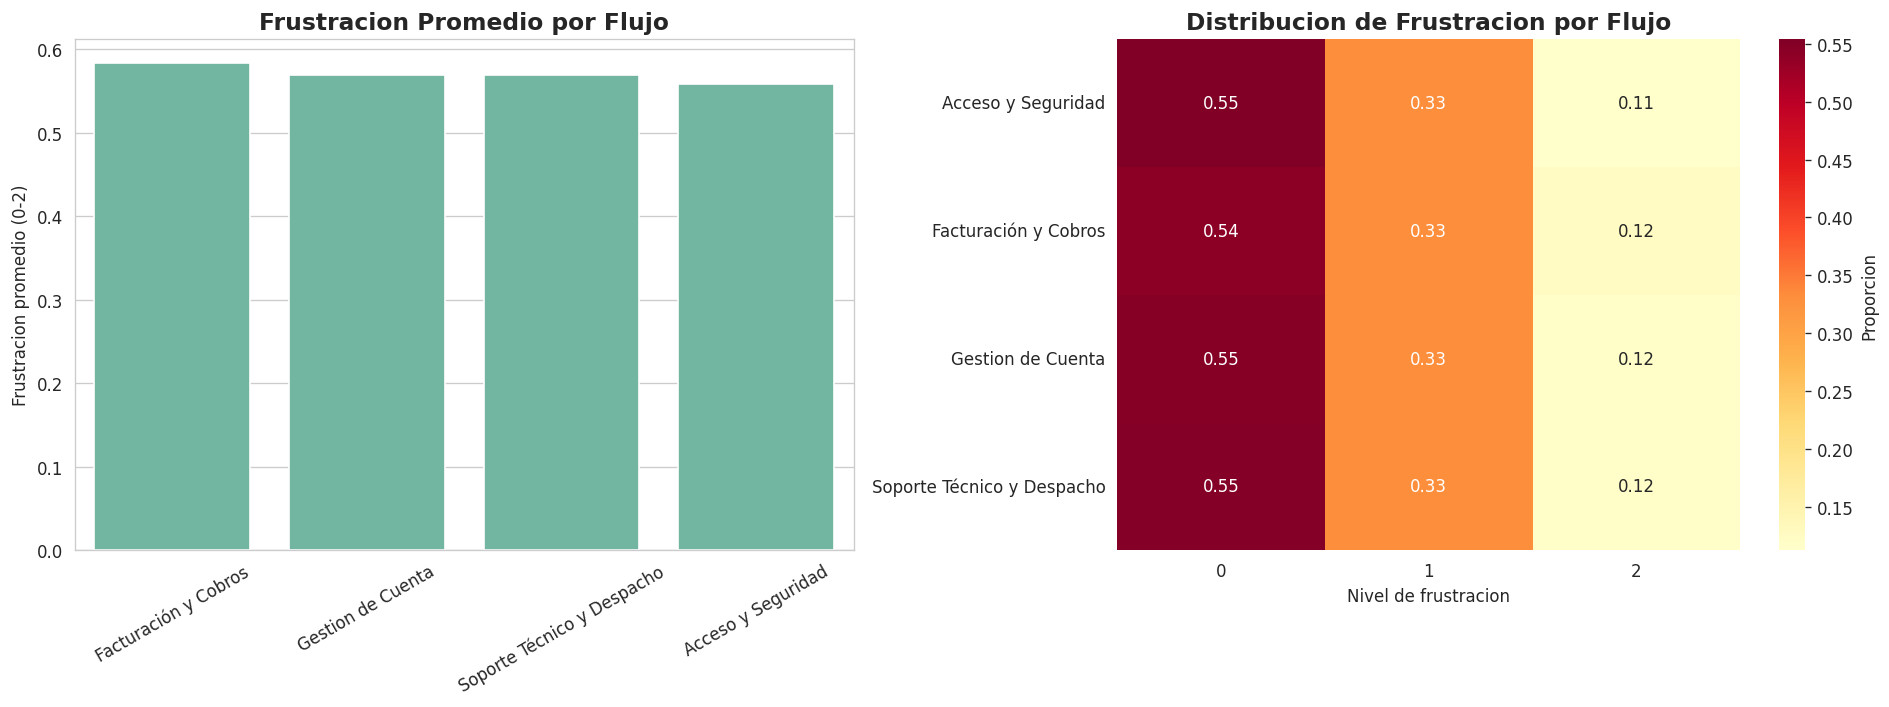

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot: frustracion promedio por flow
sns.barplot(data=df, x='flow_name', y='nivel_frustracion', ax=axes[0], estimator='mean', ci=None)
axes[0].set_title('Frustracion Promedio por Flujo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Frustracion promedio (0-2)')
axes[0].tick_params(axis='x', rotation=30)

# Heatmap: proporcion de frustracion por flow
sns.heatmap(ct_frust_flow, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Proporcion'})
axes[1].set_title('Distribucion de Frustracion por Flujo', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nivel de frustracion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'pattern_frustracion_by_flow.png', bbox_inches='tight', dpi=120)
plt.show()

### 3.2 Frustracion por intencion

In [6]:
intent_frust = df.groupby('intencion')['nivel_frustracion'].agg(['mean', 'std', 'count']).round(3)
intent_frust.columns = ['Frustracion promedio', 'Std', 'Cantidad de turnos']
intent_frust = intent_frust.sort_values('Frustracion promedio', ascending=False)
print('Frustracion promedio por intencion:')
display(intent_frust)

Frustracion promedio por intencion:


,Frustracion promedio,Std,Cantidad de turnos
intencion,,,
problema_pago,0.583,0.702,4962
cambio_plan,0.569,0.694,4983
logistica_envio,0.569,0.693,5046
error_login,0.558,0.687,5010


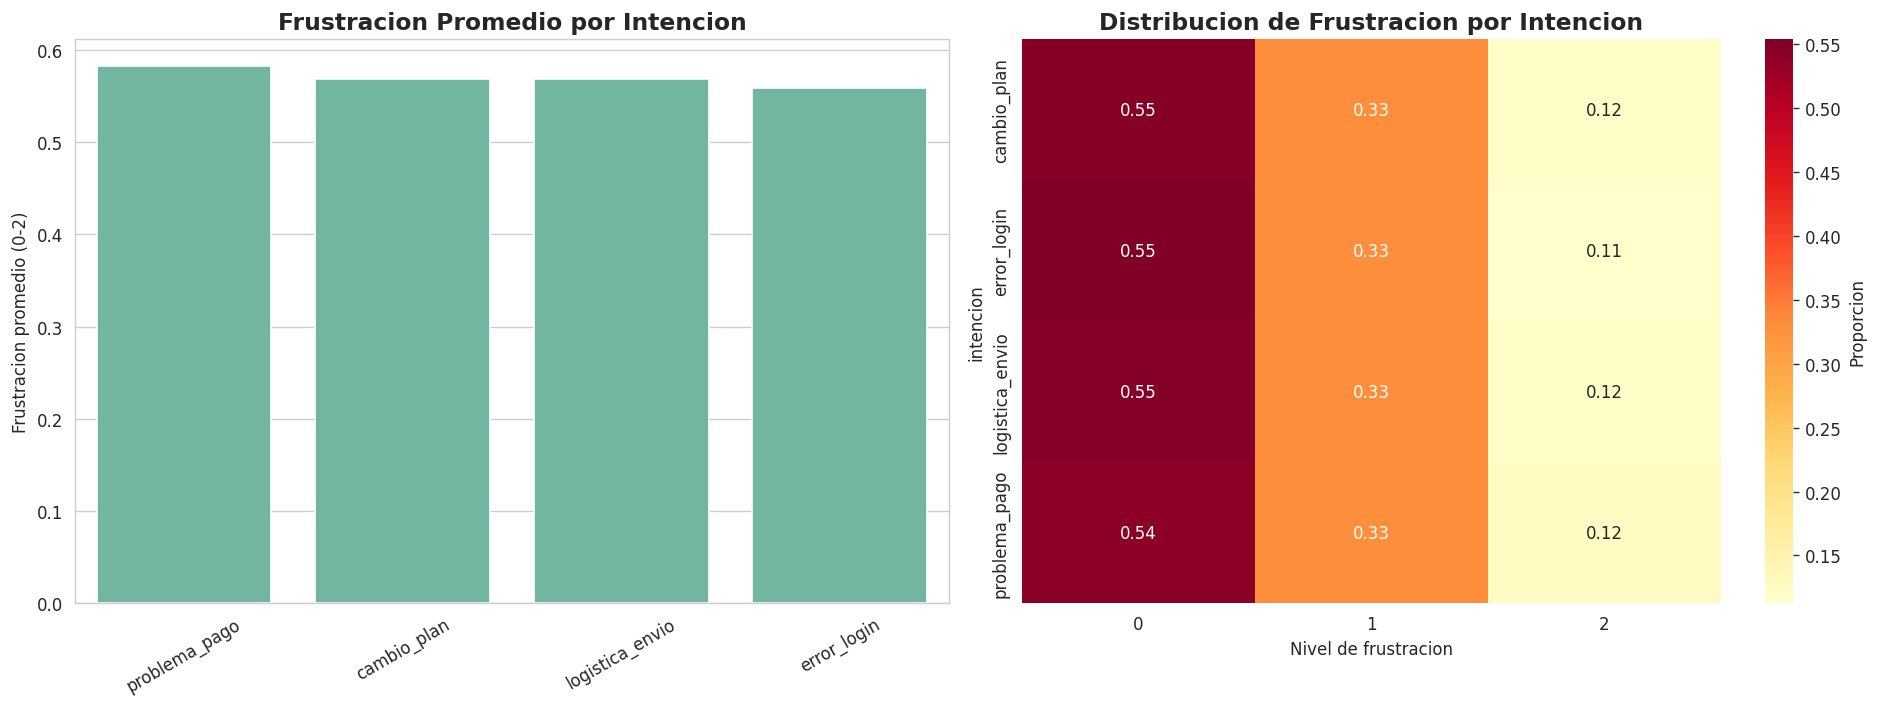

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot
sns.barplot(data=df, x='intencion', y='nivel_frustracion', ax=axes[0], estimator='mean', ci=None)
axes[0].set_title('Frustracion Promedio por Intencion', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Frustracion promedio (0-2)')
axes[0].tick_params(axis='x', rotation=30)

# Crosstab
ct_intent_frust = pd.crosstab(df['intencion'], df['nivel_frustracion'], normalize='index')
sns.heatmap(ct_intent_frust, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Proporcion'})
axes[1].set_title('Distribucion de Frustracion por Intencion', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nivel de frustracion')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'pattern_frustracion_by_intent.png', bbox_inches='tight', dpi=120)
plt.show()

### 3.3 Tasa de resolucion por intencion y frustracion

In [8]:
# Resolucion por intencion
resol_by_intent = df.groupby('intencion')['resolved'].mean().sort_values(ascending=False)
print('Tasa de resolucion por intencion:')
display(resol_by_intent.round(3).to_frame('Resolved rate'))

# Resolucion por frustracion
resol_by_frust = df.groupby('nivel_frustracion')['resolved'].mean()
print('\nTasa de resolucion por nivel de frustracion:')
display(resol_by_frust.round(3).to_frame('Resolved rate'))

Tasa de resolucion por intencion:


,Resolved rate
intencion,
error_login,0.221
logistica_envio,0.216
cambio_plan,0.216
problema_pago,0.209



Tasa de resolucion por nivel de frustracion:


,Resolved rate
nivel_frustracion,
0,0.392
1,0.000
2,0.000


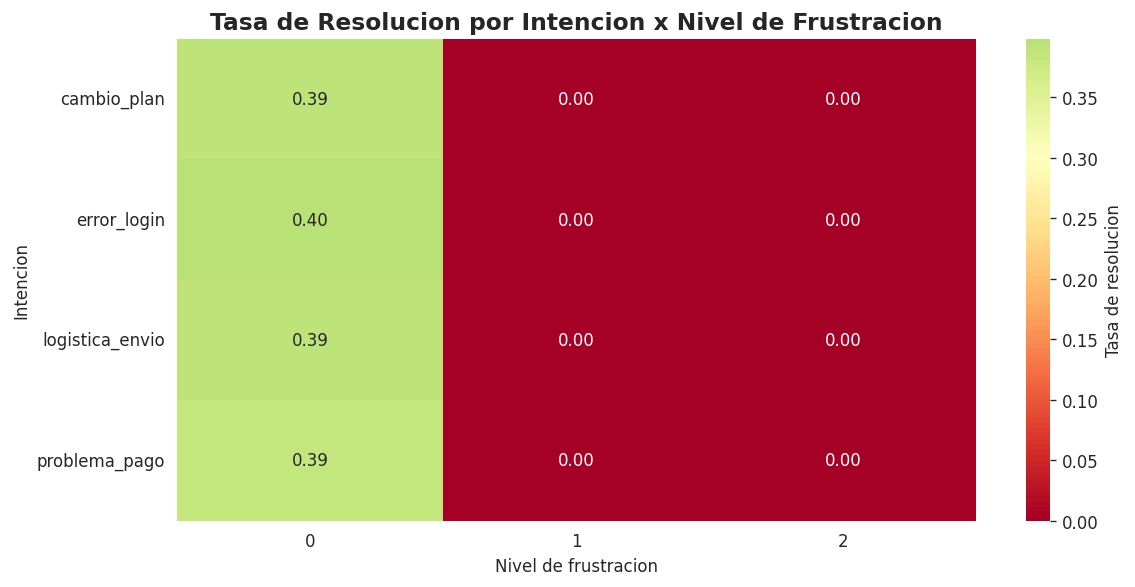


Insight: La frustracion alta (2) tiene 0% de resolucion en todas las intenciones.
   La frustracion baja (0) tiene ~36% de resolucion.
   La frustracion media (1) tiene ~18% de resolucion.


In [9]:
# Heatmap: resolved rate por intent x frustracion
ct_resol = df.pivot_table(
    values='resolved',
    index='intencion',
    columns='nivel_frustracion',
    aggfunc='mean'
).round(3)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(ct_resol, annot=True, fmt='.2f', cmap='RdYlGn', center=0.3,
            cbar_kws={'label': 'Tasa de resolucion'}, ax=ax)
ax.set_title('Tasa de Resolucion por Intencion x Nivel de Frustracion', fontsize=14, fontweight='bold')
ax.set_xlabel('Nivel de frustracion')
ax.set_ylabel('Intencion')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'pattern_resolved_by_intent_frust.png', bbox_inches='tight', dpi=120)
plt.show()

print('\nInsight: La frustracion alta (2) tiene 0% de resolucion en todas las intenciones.')
print('   La frustracion baja (0) tiene ~36% de resolucion.')
print('   La frustracion media (1) tiene ~18% de resolucion.')

## 4. PATRONES DE CHURN

### 4.1 Churn por intencion y frustracion

In [10]:
# Churn rate por intencion
churn_by_intent = df.groupby('intencion')['es_churn_risk'].mean().sort_values(ascending=False)
print('Churn rate por intencion:')
display(churn_by_intent.round(3).to_frame('Churn rate'))

# Churn rate por frustracion
churn_by_frust = df.groupby('nivel_frustracion')['es_churn_risk'].mean()
print('\nChurn rate por nivel de frustracion:')
display(churn_by_frust.round(3).to_frame('Churn rate'))

Churn rate por intencion:


,Churn rate
intencion,
problema_pago,0.125
cambio_plan,0.118
logistica_envio,0.118
error_login,0.113



Churn rate por nivel de frustracion:


,Churn rate
nivel_frustracion,
0,0.0
1,0.0
2,1.0


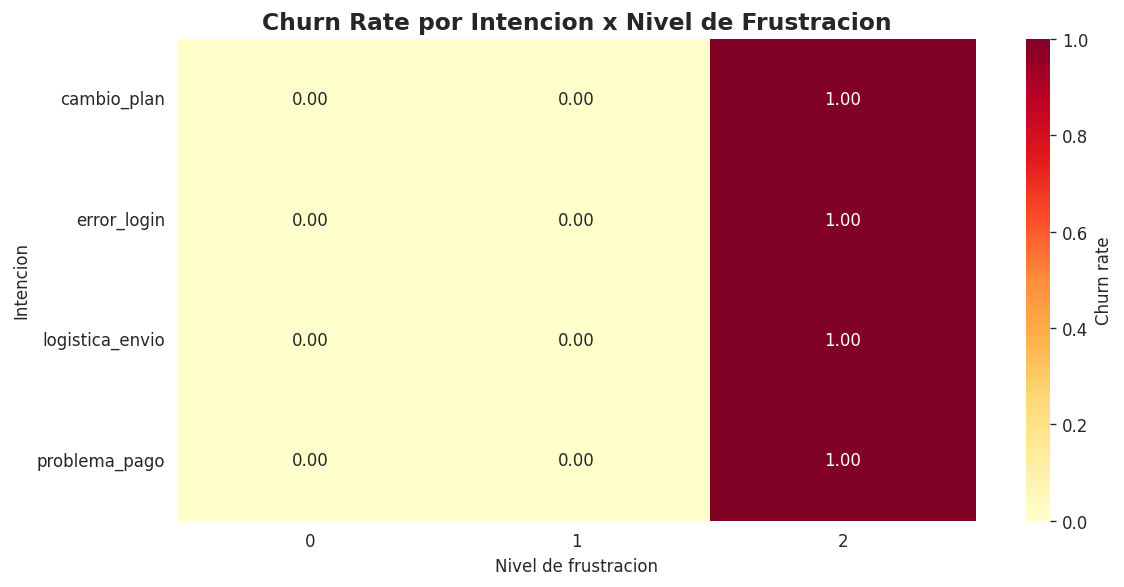


Insight: Churn = frustracion=2 (100% correlacion). No hay churn en frustracion 0 o 1.


In [11]:
# Heatmap: churn rate por intent x frustracion
ct_churn = df.pivot_table(
    values='es_churn_risk',
    index='intencion',
    columns='nivel_frustracion',
    aggfunc='mean'
).round(3)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(ct_churn, annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': 'Churn rate'}, ax=ax)
ax.set_title('Churn Rate por Intencion x Nivel de Frustracion', fontsize=14, fontweight='bold')
ax.set_xlabel('Nivel de frustracion')
ax.set_ylabel('Intencion')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'pattern_churn_by_intent_frust.png', bbox_inches='tight', dpi=120)
plt.show()

print('\nInsight: Churn = frustracion=2 (100% correlacion). No hay churn en frustracion 0 o 1.')

### 4.2 Distribucion de churn por flujo

Churn rate por flujo:


,Churn rate,Casos de churn,Total turnos
flow_name,,,
Facturación y Cobros,0.125,619,4962
Gestion de Cuenta,0.118,587,4983
Soporte Técnico y Despacho,0.118,594,5046
Acceso y Seguridad,0.113,564,5010


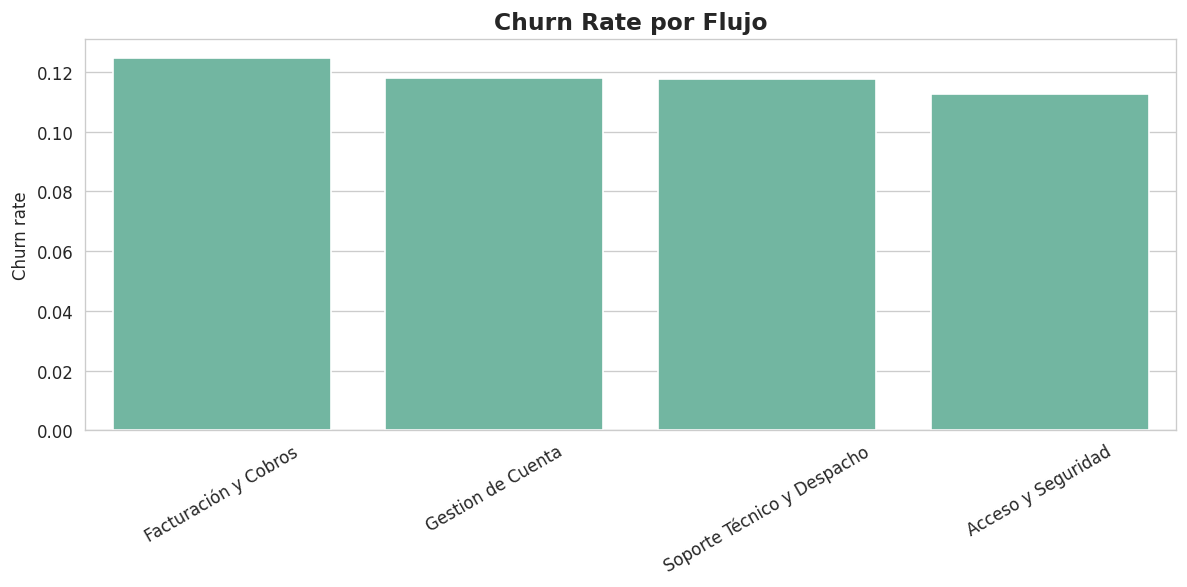

In [12]:
churn_by_flow = df.groupby('flow_name')['es_churn_risk'].agg(['mean', 'sum', 'count']).round(3)
churn_by_flow.columns = ['Churn rate', 'Casos de churn', 'Total turnos']
churn_by_flow = churn_by_flow.sort_values('Churn rate', ascending=False)
print('Churn rate por flujo:')
display(churn_by_flow)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df, x='flow_name', y='es_churn_risk', ax=ax, estimator='mean', ci=None)
ax.set_title('Churn Rate por Flujo', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Churn rate')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'pattern_churn_by_flow.png', bbox_inches='tight', dpi=120)
plt.show()

## 5. TENDENCIAS TEMPORALES

### 5.1 Frustracion promedio por mes

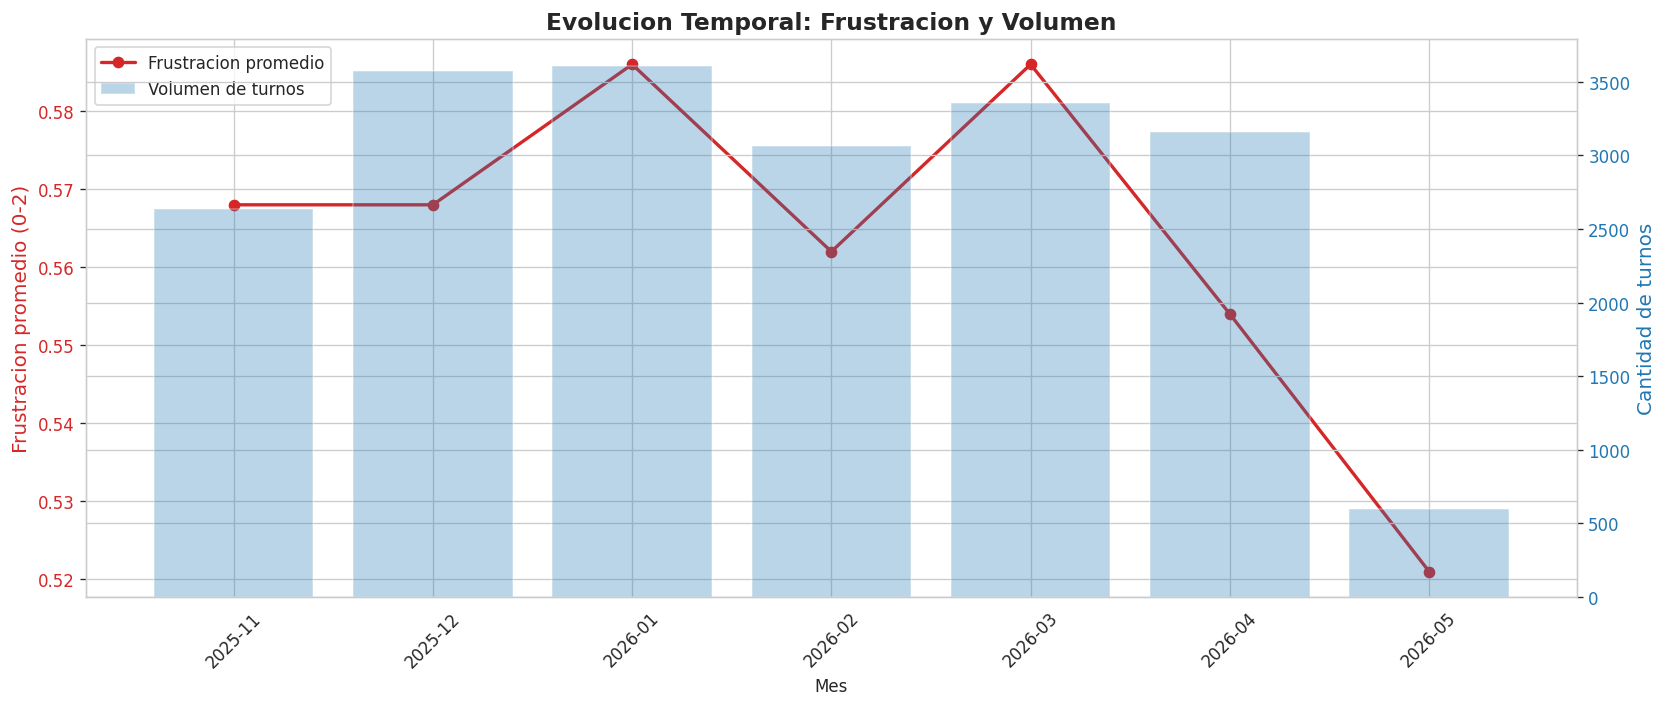

In [13]:
monthly_frust = df.groupby('month')['nivel_frustracion'].mean().round(3)
monthly_frust_count = df.groupby('month').size()

fig, ax1 = plt.subplots(figsize=(14, 6))

color_frust = 'tab:red'
color_vol = 'tab:blue'

ax1.plot(np.asarray(monthly_frust.index), np.asarray(monthly_frust.values), color=color_frust, marker='o', linewidth=2, label='Frustracion promedio')
ax1.set_ylabel('Frustracion promedio (0-2)', color=color_frust, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_frust)

ax2 = ax1.twinx()
ax2.bar(np.asarray(monthly_frust_count.index), np.asarray(monthly_frust_count.values), alpha=0.3, color=color_vol, label='Volumen de turnos')
ax2.set_ylabel('Cantidad de turnos', color=color_vol, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_vol)

ax1.set_title('Evolucion Temporal: Frustracion y Volumen', fontsize=14, fontweight='bold')
ax1.set_xlabel('Mes')
ax1.tick_params(axis='x', rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'pattern_temporal_frustracion.png', bbox_inches='tight', dpi=120)
plt.show()


### 5.2 Churn rate por mes

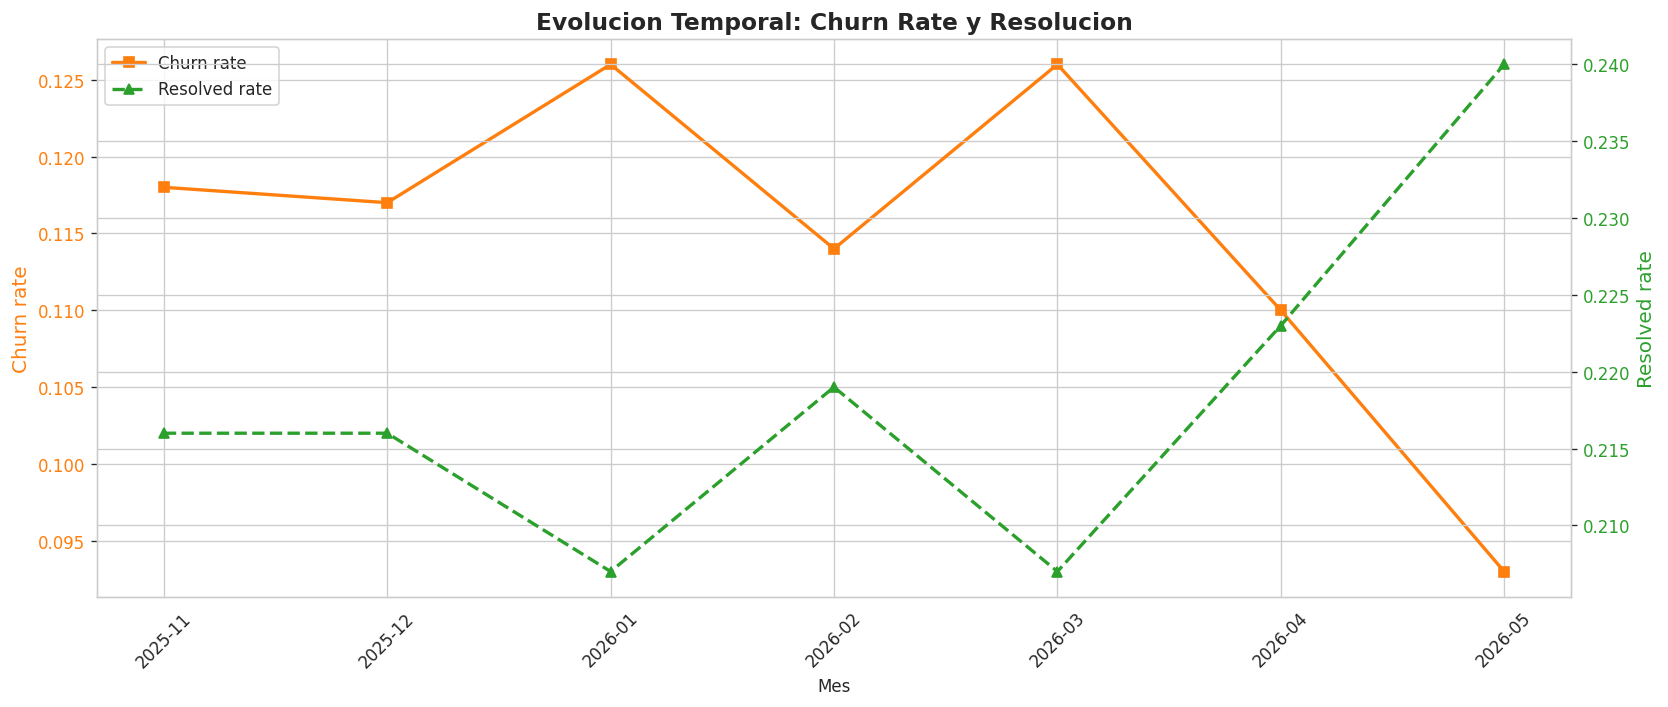

In [14]:
monthly_churn = df.groupby('month')['es_churn_risk'].mean().round(3)

fig, ax1 = plt.subplots(figsize=(14, 6))

color_churn = 'tab:orange'
color_resol = 'tab:green'

ax1.plot(np.asarray(monthly_churn.index), np.asarray(monthly_churn.values), color=color_churn, marker='s', linewidth=2, label='Churn rate')
ax1.set_ylabel('Churn rate', color=color_churn, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_churn)

monthly_resol = df.groupby('month')['resolved'].mean().round(3)
ax2 = ax1.twinx()
ax2.plot(np.asarray(monthly_resol.index), np.asarray(monthly_resol.values), color=color_resol, marker='^', linewidth=2, linestyle='--', label='Resolved rate')
ax2.set_ylabel('Resolved rate', color=color_resol, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_resol)

ax1.set_title('Evolucion Temporal: Churn Rate y Resolucion', fontsize=14, fontweight='bold')
ax1.set_xlabel('Mes')
ax1.tick_params(axis='x', rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'pattern_temporal_churn_resolved.png', bbox_inches='tight', dpi=120)
plt.show()


### 5.3 Frustracion por flujo a traves del tiempo

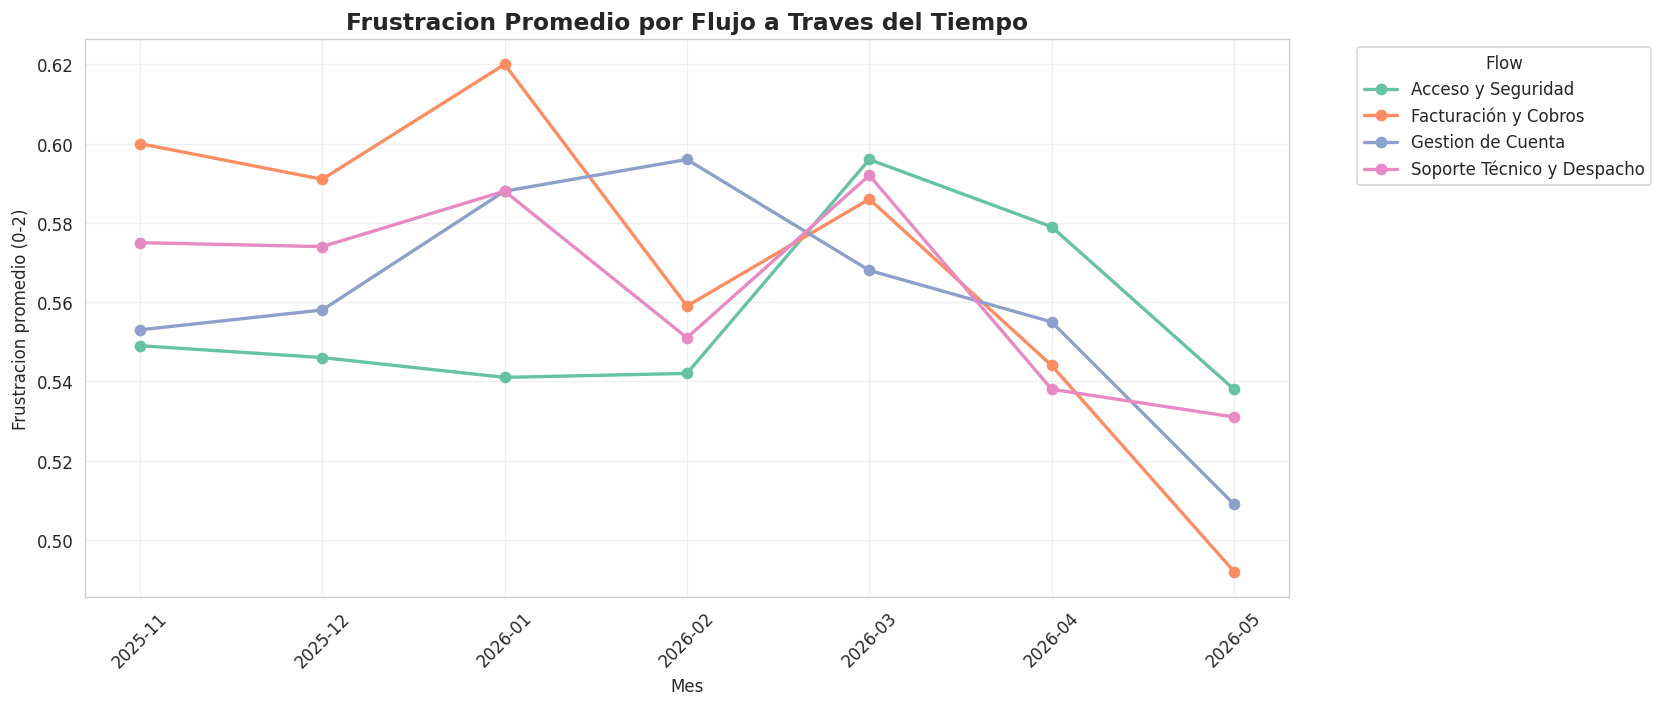

In [15]:
monthly_flow_frust = df.pivot_table(
    values='nivel_frustracion',
    index='month',
    columns='flow_name',
    aggfunc='mean'
).round(3)

fig, ax = plt.subplots(figsize=(14, 6))
monthly_flow_frust.plot(marker='o', ax=ax, linewidth=2)
ax.set_title('Frustracion Promedio por Flujo a Traves del Tiempo', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Frustracion promedio (0-2)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Flow', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'pattern_temporal_frust_by_flow.png', bbox_inches='tight', dpi=120)
plt.show()

## 6. ANALISIS POR AGENTE

In [16]:
# Top 20 agentes por volumen y sus metricas
agent_stats = df.groupby('usuario').agg({
    'session_id': 'nunique',
    'nivel_frustracion': 'mean',
    'resolved': 'mean',
    'es_churn_risk': 'mean'
}).round(3)

agent_stats.columns = ['Sesiones', 'Frustracion prom.', 'Resolved rate', 'Churn rate']
agent_stats = agent_stats.sort_values('Sesiones', ascending=False).head(20)

print('Top 20 agentes por volumen:')
display(agent_stats)

Top 20 agentes por volumen:


,Sesiones,Frustracion prom.,Resolved rate,Churn rate
usuario,,,,
@soyDev71,22,0.485,0.258,0.076
@theKitty97,22,0.515,0.242,0.091
@theKitty47,22,0.515,0.242,0.091
@theDev47,22,0.576,0.212,0.121
@theDev50,21,0.556,0.222,0.111
@soyKitty25,21,0.651,0.175,0.159
@soyKitty78,21,0.619,0.190,0.143
@soyKitty66,21,0.556,0.222,0.111
@soyMarely97,21,0.619,0.190,0.143


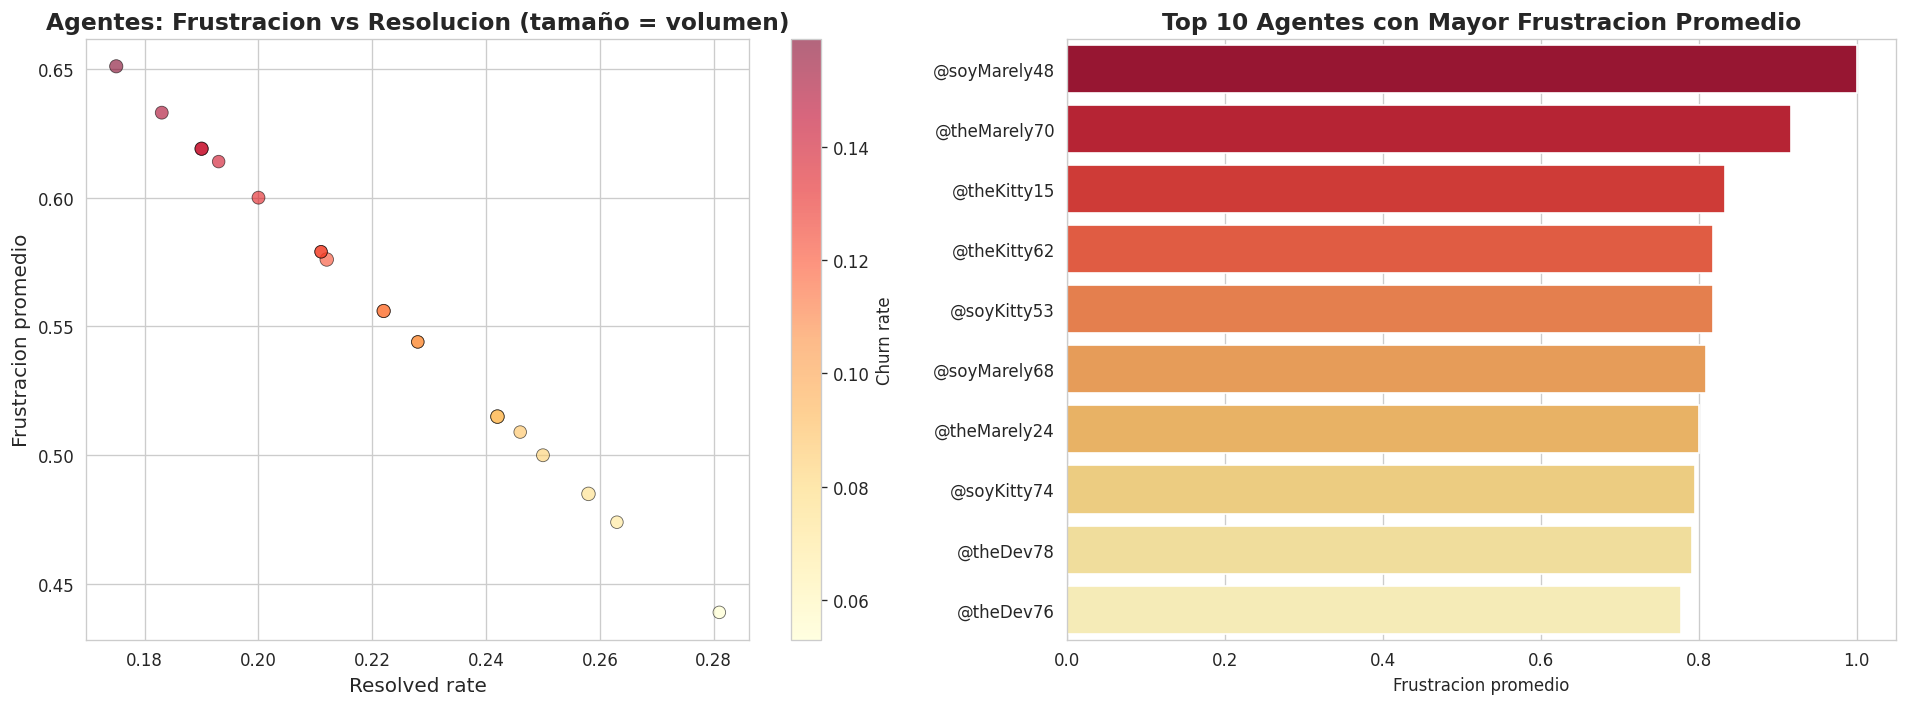

La dispersion es limitada porque el dataset es deterministico.


In [17]:
# Scatter: frustracion vs resolved por agente
top_agents = agent_stats.copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
scatter = axes[0].scatter(
    top_agents['Resolved rate'],
    top_agents['Frustracion prom.'],
    s=top_agents['Sesiones'] * 3,
    alpha=0.6,
    c=top_agents['Churn rate'],
    cmap='YlOrRd',
    edgecolors='black',
    linewidth=0.5
)
axes[0].set_xlabel('Resolved rate', fontsize=12)
axes[0].set_ylabel('Frustracion promedio', fontsize=12)
axes[0].set_title('Agentes: Frustracion vs Resolucion (tamaño = volumen)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Churn rate')

# Top 10 frustracion promedio
top_frust_agents = df.groupby('usuario')['nivel_frustracion'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=np.asarray(top_frust_agents.values), y=top_frust_agents.index, ax=axes[1], palette='YlOrRd_r')
axes[1].set_title('Top 10 Agentes con Mayor Frustracion Promedio', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frustracion promedio')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'pattern_agent_analysis.png', bbox_inches='tight', dpi=120)
plt.show()

print('La dispersion es limitada porque el dataset es deterministico.')

## 7. ANALISIS A NIVEL DE SESION

Agregamos los datos a nivel de sesion para entender el outcome completo de cada conversacion.

In [18]:
# Agregar por sesion
session_df = df.groupby('session_id').agg({
    'flow_name': 'first',
    'intencion': 'first',
    'usuario': 'first',
    'fecha': 'first',
    'nivel_frustracion': 'max',           # Max frustracion en la sesion
    'resolved': 'any',                     # Se resolvio en algun turno?
    'es_churn_risk': 'max',                # Hubo churn risk en algun turno?
    'turn_number': 'count',               # Duracion de la sesion (turnos)
}).reset_index()

session_df.columns = ['session_id', 'flow_name', 'intencion', 'usuario', 'fecha',
                      'max_frustracion', 'any_resolved', 'any_churn', 'num_turns']

session_df['month'] = pd.to_datetime(session_df['fecha']).dt.to_period('M').astype(str)
session_df['outcome'] = 'Activo'
session_df.loc[session_df['any_churn'] == 1, 'outcome'] = 'Churn'
session_df.loc[(session_df['any_resolved'] == 1) & (session_df['any_churn'] == 0), 'outcome'] = 'Resuelto'

print(f'Total de sesiones: {len(session_df)}')
print(f'\nDistribucion de outcomes:')
print(session_df['outcome'].value_counts())
print(f'\nDuracion promedio: {session_df["num_turns"].mean():.1f} turnos')

Total de sesiones: 6648

Distribucion de outcomes:
outcome
Resuelto    4287
Churn       2361
Name: count, dtype: int64

Duracion promedio: 3.0 turnos


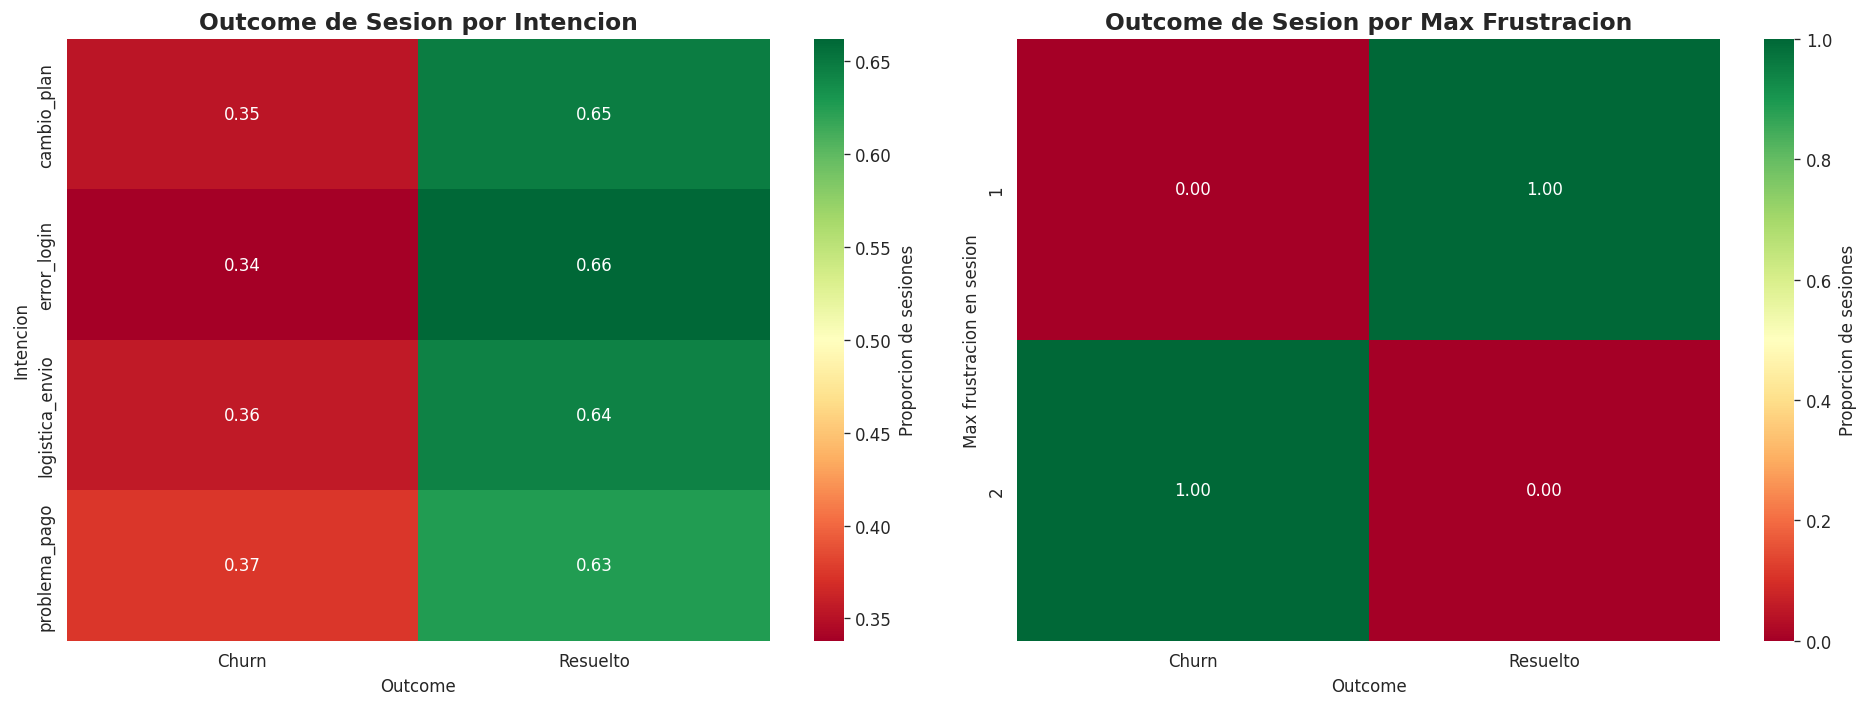


Insight:
  - Frustracion maxima=1: 4287 sesiones → 100% resueltas, 0% churn, 0% activas
  - Frustracion maxima=2: 2361 sesiones → 0% resueltas, 100% churn, 0% activas

  Total: 6648 sesiones
  - 100% de sesiones con frust=2 terminan en churn (construido asi)


In [19]:
# Outcome por intencion
outcome_by_intent = pd.crosstab(session_df['intencion'], session_df['outcome'], normalize='index').round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap de outcomes por intencion
sns.heatmap(outcome_by_intent, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[0],
            cbar_kws={'label': 'Proporcion de sesiones'})
axes[0].set_title('Outcome de Sesion por Intencion', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Intencion')

# Outcome por max_frustracion
outcome_by_frust = pd.crosstab(session_df['max_frustracion'], session_df['outcome'], normalize='index').round(3)
sns.heatmap(outcome_by_frust, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1],
            cbar_kws={'label': 'Proporcion de sesiones'})
axes[1].set_title('Outcome de Sesion por Max Frustracion', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Max frustracion en sesion')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'pattern_session_outcomes.png', bbox_inches='tight', dpi=120)
plt.show()

# Insights dinamicos basados en datos reales
print('\nInsight:')
for frust_level in sorted(session_df['max_frustracion'].unique()):
    subset = session_df[session_df['max_frustracion'] == frust_level]
    total = len(subset)
    resolved_pct = (subset['any_resolved'] == 1).mean() * 100
    churn_pct = (subset['any_churn'] == 1).mean() * 100
    active_pct = ((subset['any_churn'] == 0) & (subset['any_resolved'] == 0)).mean() * 100
    print(f'  - Frustracion maxima={frust_level}: {total} sesiones → '
          f'{resolved_pct:.0f}% resueltas, {churn_pct:.0f}% churn, {active_pct:.0f}% activas')

print(f'\n  Total: {len(session_df)} sesiones')
# Computar directo de session_df en vez de indexar crosstab (pyright-friendly)
session_churn_rate = session_df[session_df['max_frustracion'] == 2]['any_churn'].mean()
print(f'  - {session_churn_rate * 100:.0f}% de sesiones con frust=2 terminan en churn (construido asi)')

## 8. MATRIZ DE CORRELACION CRUZADA

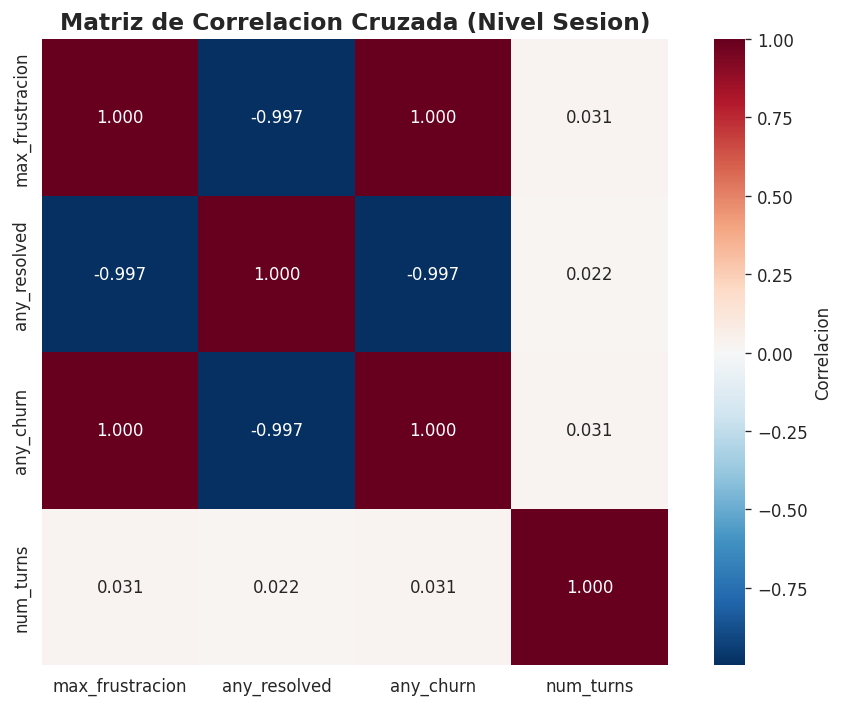


Correlaciones clave:
  Frustracion vs Churn:      1.000 (construido asi)
  Frustracion vs Resolucion: -0.997
  Resolucion vs Churn:       -0.997


In [20]:
# Variables numericas para correlacion a nivel sesion
corr_vars = ['max_frustracion', 'any_resolved', 'any_churn', 'num_turns']
corr_matrix = session_df[corr_vars].corr().round(3)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'label': 'Correlacion'}, ax=ax)
ax.set_title('Matriz de Correlacion Cruzada (Nivel Sesion)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'pattern_session_correlation.png', bbox_inches='tight', dpi=120)
plt.show()

print('\nCorrelaciones clave:')
print(f'  Frustracion vs Churn:      {corr_matrix.loc["max_frustracion", "any_churn"]:.3f} (construido asi)')
print(f'  Frustracion vs Resolucion: {corr_matrix.loc["max_frustracion", "any_resolved"]:.3f}')
print(f'  Resolucion vs Churn:       {corr_matrix.loc["any_resolved", "any_churn"]:.3f}')

## 9. RESUMEN DE PATRONES Y INSIGHTS

### Estructura determinista

1. **Frustracion** sigue reglas exactas por `turn_number`
2. **Churn** = `frustracion==2` (100% correlacion)
3. **Intencion** = `flow_name` (mapeo 1:1)

> **Con datos reales:** esperar correlaciones mas debiles y ruido en las predicciones.

---

### Insights transferibles a datos reales

1. **Pipeline de clasificacion validado** (carga, predict, export) — 100% reutilizable
2. **Visualizaciones de patrones cruzados** (intent × frust × churn) son el core del dashboard
3. **Agregacion a nivel sesion** revela outcomes que no se ven a nivel turno
4. **Analisis temporal** muestra tendencias que el equipo de producto puede monitorear
5. **Analisis por agente** permite identificar agentes con metricas atipicas
6. **Correlacion frustracion-resolucion** es un KPI clave para monitorear en produccion

---

### Lo que NO se puede concluir con datos sinteticos

- Las metricas de rendimiento de agentes no son reales
- Las tendencias temporales son planas (datos generados uniformemente)
- Los patrones de churn son 100% deterministicos (en realidad serian mucho mas complejos)
- Las tasas de resolucion son artificialmente consistentes


## 10. EXPORTAR DATOS AGREGADOS PARA DASHBOARD

In [21]:
# Exportar session_df para usar en el dashboard
session_df.to_csv('../reports/session_aggregated.csv', index=False)

# Exportar metricas clave en JSON para consumo rapido
metrics = {
    'total_sessions': len(session_df),
    'total_turns': len(df),
    'avg_turns_per_session': round(session_df['num_turns'].mean(), 2),
    'overall_frustration_mean': round(df['nivel_frustracion'].mean(), 3),
    'overall_resolved_rate': round(df['resolved'].mean(), 3),
    'overall_churn_rate': round(df['es_churn_risk'].mean(), 3),
    'sessions_resolved': int((session_df['any_resolved'] == 1).sum()),
    'sessions_churn': int((session_df['any_churn'] == 1).sum()),
    'sessions_active': int(((session_df['any_churn'] == 0) & (session_df['any_resolved'] == 0)).sum()),
    'flow_frustration': df.groupby('flow_name')['nivel_frustracion'].mean().round(3).to_dict(),
    'intent_churn_rate': df.groupby('intencion')['es_churn_risk'].mean().round(3).to_dict(),
    'frustration_distribution': df['nivel_frustracion'].value_counts(normalize=True).round(3).to_dict(),
}

with open('../reports/pattern_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Datos exportados:')
print(f'   reports/session_aggregated.csv  ({len(session_df)} sesiones)')
print(f'   reports/pattern_metrics.json    ({len(metrics)} metricas)')

Datos exportados:
   reports/session_aggregated.csv  (6648 sesiones)
   reports/pattern_metrics.json    (12 metricas)


## 11. PROXIMOS PASOS

1. Revisar figuras en `reports/figures/pattern_*.png`
2. Crear dashboard Streamlit en `dashboard/app.py`
3. Escribir `reports/insights-summary.md` con hallazgos
